In [2]:
import os
import re
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as md
#from scipy.stats import chisquare
from datetime import datetime, timedelta
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

In [97]:
BASIC_PATH = '/Users/rudolf/findyr_prjs/natural-language-processing/'
DATASET_PATH = 'datasets/twitter/cyberattack/'
ENGLISH_STOPWORDS = list(set(stopwords.words("english")))
MIN_MENTIONS = 10
RATIO_DIFF = 10

In [98]:
df_1 = pd.read_csv(os.path.join(BASIC_PATH, DATASET_PATH, 'cyberattack_2018_02_03.csv'))
df_2 = pd.read_csv(os.path.join(BASIC_PATH, DATASET_PATH, 'cyberattack_2018_03_04.csv'))
df_3 = pd.read_csv(os.path.join(BASIC_PATH, DATASET_PATH, 'cyberattack_2018_04_05.csv'))
df = pd.concat([df_1, df_2, df_3])

df = df[['time_stamp', 'text', 'user']]
df.dropna(inplace=True)
df['time_stamp'] = pd.to_datetime(df.time_stamp, format='%Y-%m-%d %H:%M:%S')
df = df.set_index('time_stamp')

In [99]:
def preprocess(raw_text):

    # remove urls
    raw_text = re.sub(r"http\S+", "", str(raw_text))

    # remove twitter specific words
    raw_text = re.sub('(RT)|(\n)', ' ', raw_text)
    raw_text = re.sub('(from @)|(via @)|(by @)', ' @', raw_text)
    raw_text = re.sub(r'[ ]{2,}', ' ', raw_text).strip()

    # remove usernames
    raw_text = re.sub(r'(?<=^|(?<=[^a-zA-Z0-9-_\.]))@([A-Za-z]+[A-Za-z0-9-_]+)', '', raw_text, flags=re.MULTILINE)

    # remove trailing hashtags
    raw_text = re.sub(r'( #\S+)*$', '', raw_text)

    output = []
    for index, w in enumerate(raw_text.split()):
        normalized_word = re.sub(r'[^a-zA-Z\s]', '', w).lower()
        if normalized_word not in ENGLISH_STOPWORDS:
            output.append(normalized_word)
    return " ".join(output)

def get_ngrams_df(df, ngrams_range):
    word_vectorizer = CountVectorizer(ngram_range=ngrams_range, analyzer='word')
    sparse_matrix = word_vectorizer.fit_transform(df['text'])
    frequencies = sum(sparse_matrix).toarray()[0]
    return pd.DataFrame(frequencies, index=word_vectorizer.get_feature_names(), columns=['frequency'])  

In [100]:
def get_freqs(start_time):
    output = []
    for_heat_map = []
    end_time = start_time + timedelta(minutes=15)
    #print(start_time, end_time)
    outlier_day_df = df[(df.index > start_time) & (df.index < end_time)]
    outlier_day_df = outlier_day_df.drop_duplicates(subset=['text', 'user'], keep='first')
    #print(outlier_day_df)
    if len(outlier_day_df['text'].values) > 0:
        curr_res = get_ngrams_df(outlier_day_df, (1,1)).reset_index().rename(columns={'index': 'word'})
        curr_res.columns = ['word', 'count']
        curr_res['word'] = curr_res['word'].apply(preprocess)
        #curr_res = curr_res[~curr_res['word'].isin(ENGLISH_STOPWORDS)]
        curr_res.set_index('word', inplace=True)
        curr_res = curr_res.to_dict()['count']
        output.append(curr_res)
    for curr_dict in output:
        for k in curr_dict.keys():
            if len(k) > 1:
                for_heat_map.append({'time': start_time, 'word': k, 'count': curr_dict[k]})
    if len(for_heat_map) > 0:
        output_df = pd.DataFrame(for_heat_map)
        output_df = output_df.groupby(['word'])[['count']].sum().sort_values(by='count', ascending=False).reset_index()
    else:
        output_df = pd.DataFrame()
    return output_df

def calc_ratio(x):
    return (x[0]+1)/(x[1]+1)

def has_top_discussion(expected, time):
    observed = get_freqs(time) # 2018-03-15 19:00:00
    df_observed = observed.rename(columns={'count': 'observed'})
    df_expected = expected.rename(columns={'count': 'expected'})
    score = 0
    words = []
    if not df_observed.empty:
        ob_ex_df = pd.merge(df_observed, df_expected, on='word', how='left')
        ob_ex_df.replace(np.nan, 0, inplace=True)
        ob_ex_df['stat'] = ob_ex_df[['observed', 'expected']].apply(lambda x: calc_ratio(x), axis=1)
        ob_ex_df['is_topic'] = (ob_ex_df['expected'] < ob_ex_df['observed']) \
                                & (ob_ex_df['observed'] >= MIN_MENTIONS) \
                                & (ob_ex_df['stat'] > RATIO_DIFF)
                                
        for index, row in ob_ex_df[:5].iterrows():
            if row['is_topic']:
                score += 10
                words.append(row['word'])
    return score > 0, score, words

### Background model 

<b>Background models contains average count of word one month ago</b>

In [101]:
expected = []
start_time = datetime.strptime('2018-02-15 00:00:00', '%Y-%m-%d %H:%M:%S')

for i in range(124):
    start_time = start_time + timedelta(minutes=15)
    curr_df = get_freqs(start_time)
    if not curr_df.empty:
        expected.append(curr_df)
expected = pd.concat(expected)
expected = expected.groupby('word')[['count']].median().reset_index().sort_values(by='count', ascending=False)

In [102]:
#expected[expected['word'] == 'cybersecurity'].mean()

### Trend Signals 

In [103]:
# 2018-04-07 anomaly by count, no signals by topic frequency
# 2018-04-25 anomaly by count, has trending topic frequency
signals = []
start_time = datetime.strptime('2018-04-18 08:00:00', '%Y-%m-%d %H:%M:%S')
for i in range(76):
    has_topic, score, words = has_top_discussion(expected, start_time)
    signals.append({'time': start_time, 'has_topic': has_topic, 'score': score, 'words': words})
    start_time = start_time + timedelta(minutes=15)
    
final_result_df = pd.DataFrame(signals)
x_time = []
y_score = []
z_words = []
for index, row in final_result_df.iterrows():
    if row['score'] > 0:
        x_time.append(row['time'])
        y_score.append(row['score'])
        z_words.append(row['words'])

### Tweets Count 

In [105]:
resampled_data = df['2018-04-18 08:00:00':'2018-04-19 00:00:00'].\
                    resample('15Min').count()[['text']].rename(columns={'text': 'count'}).reset_index()

### Visualization 

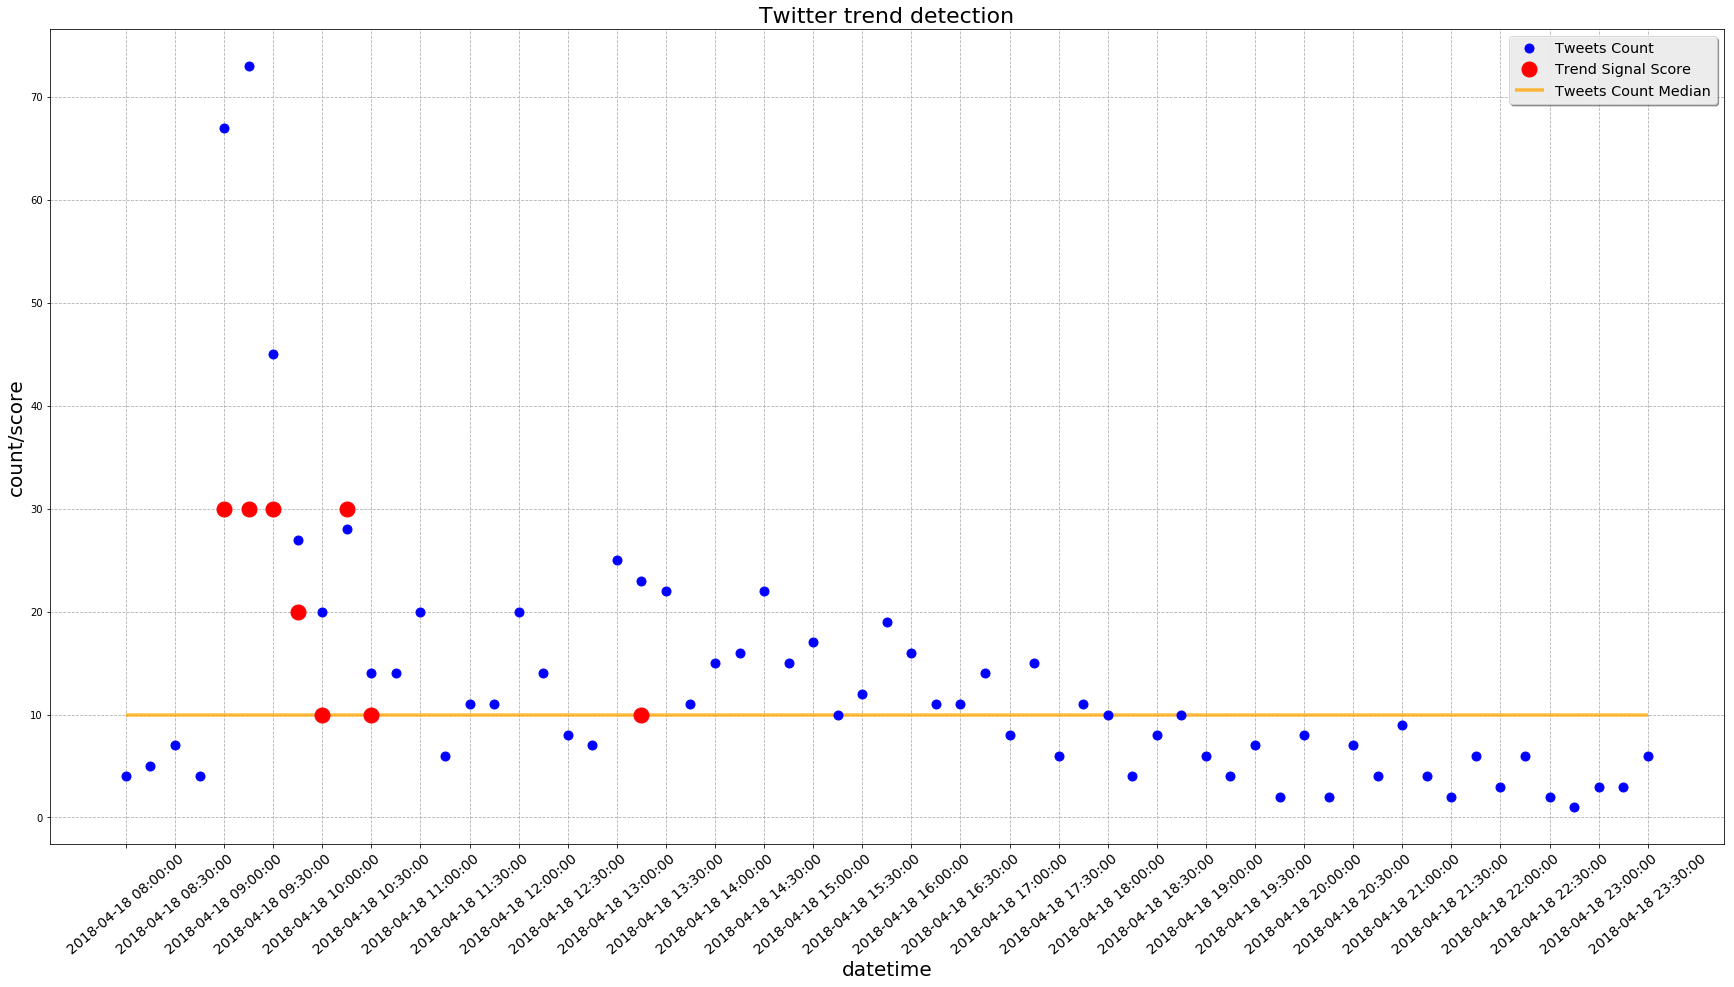

In [106]:
fig,ax= plt.subplots()
fig.set_size_inches(30, 15)
xfmt = md.DateFormatter('%Y-%m-%d %H:%M:%S')
ax.xaxis.set_major_formatter(xfmt)
plt.plot_date(resampled_data["time_stamp"].tolist(), resampled_data["count"].tolist(), markersize=9.0, marker='o', c='blue', label='Tweets Count')
plt.plot_date(x_time, y_score, marker='o', c='red', markersize=15.0, label='Trend Signal Score')
plt.hlines(y=resampled_data["count"].median(), xmin=min(resampled_data["time_stamp"].tolist()), xmax=max(resampled_data["time_stamp"].tolist()), linewidth=3.5, alpha=0.75, color='orange', label='Tweets Count Median')
plt.grid(True, which="both", linestyle='--')
plt.legend(loc='upper right', shadow=True, fontsize='x-large')
plt.title('Twitter trend detection', fontsize=22)
plt.xlabel('datetime', fontsize=20)
plt.ylabel('count/score', fontsize=20)
plt.xticks([v for i, v in enumerate(resampled_data["time_stamp"].tolist()) if i%2 == 0], rotation=40, fontsize=14)
plt.show()

In [107]:
dict(zip(x_time, z_words))

{Timestamp('2018-04-18 09:00:00'): ['microsoft', 'facebook', 'pledge'],
 Timestamp('2018-04-18 09:15:00'): ['facebook', 'microsoft', 'pledge'],
 Timestamp('2018-04-18 09:30:00'): ['facebook', 'microsoft', 'sign'],
 Timestamp('2018-04-18 09:45:00'): ['pledge', 'facebook'],
 Timestamp('2018-04-18 10:00:00'): ['pledge'],
 Timestamp('2018-04-18 10:15:00'): ['microsoft', 'pledge', 'facebook'],
 Timestamp('2018-04-18 10:30:00'): ['pledge'],
 Timestamp('2018-04-18 13:15:00'): ['recode']}

In [320]:
aa = df['2018-04-18 23:00:00':'2018-04-19 23:30:00']
#aa#aa[aa.text.str.contains('tax', regex=False)]

## Looking for outliers and anomalies

In [92]:
# sns.boxplot(x=resampled_data['count'])
# plt.show()

In [93]:
Q1 = resampled_data.quantile(0.25)
Q3 = resampled_data.quantile(0.75)
IQR = Q3 - Q1

resampled_data[(resampled_data['count'] < (Q1 - 1.5 * IQR)['count']) | (resampled_data['count'] > (Q3 + 1.5 * IQR)['count'])]

,time_stamp,count
15,2018-04-18 09:00:00,67
16,2018-04-18 09:15:00,73
17,2018-04-18 09:30:00,45
